In [12]:
# ── 1. Dependencias ──────────────────────────────────────────────────────────
!pip install gymnasium --quiet

# ── 2. Importaciones ─────────────────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
import random
from IPython.display import clear_output
warnings.filterwarnings("ignore")

# ── 3. Reproducibilidad ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
np.random.default_rng(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── 4. Estética de gráficos ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

BLUE = "#1565C0"   # Color para SARSA a lo largo del notebook

print("✓ Entorno listo.")
print(f"  gymnasium {gym.__version__}")

✓ Entorno listo.
  gymnasium 1.2.3


## Sección 1 · El Entorno: Taxi-v3

`Taxi-v3` es un entorno estructurado de 500 estados utilizado para evaluar la escalabilidad de algoritmos tabulares.  

**Características del Entorno:**
* **Estados (500):** Combina 25 posiciones del taxi (cuadrícula 5x5), 5 posiciones posibles del pasajero (4 ubicaciones + dentro del taxi) y 4 destinos posibles.
* **Acciones (6):** Moverse al Sur, Norte, Este, Oeste, Recoger pasajero (Pickup) y Dejar pasajero (Dropoff).
* **Recompensas:**
  * **-1** por cada paso ejecutado (presiona al agente a encontrar la ruta más rápida).
  * **+20** por dejar al pasajero en su destino correctamente.
  * **-10** por ejecutar erróneamente *Pickup* o *Dropoff* en ubicaciones no válidas.

In [13]:
env_info = gym.make("Taxi-v3")

print("Taxi-v3 Environment")
print(f"  Estados : {env_info.observation_space.n}")
print(f"  Acciones : {env_info.action_space.n}")
print(f"  Recompensas : −1 por paso | +20 éxito | -10 error de pasajero")

env_info.close()

Taxi-v3 Environment
  Estados : 500
  Acciones : 6
  Recompensas : −1 por paso | +20 éxito | -10 error de pasajero


## 2. El algoritmo SARSA

El método **SARSA** actualiza los valores de la función $Q(s, a)$ basándose en la quíntupla de eventos $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$. Es un método **On-Policy**, lo que significa que evalúa y mejora la misma política que utiliza para tomar decisiones.

La regla de actualización es:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$

Donde:
* $\alpha$ es la tasa de aprendizaje.
* $\gamma$ es el factor de descuento.

In [14]:
def choose_action(state, Q_table, epsilon, env):
    """Política Epsilon-Greedy para seleccionar acciones"""
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Exploración
    else:
        return np.argmax(Q_table[state, :]) # Explotación

def train_sarsa(env, episodes, alpha, gamma, epsilon_start, epsilon_decay, epsilon_min):
    """Bucle principal de entrenamiento SARSA"""
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    stats_rewards = []
    stats_lengths = []

    epsilon = epsilon_start

    for ep in range(episodes):
        state, _ = env.reset()
        action = choose_action(state, Q_table, epsilon, env)

        total_reward = 0
        steps = 0
        done = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # SARSA: Elegimos la siguiente acción ANTES de actualizar
            next_action = choose_action(next_state, Q_table, epsilon, env)

            # Actualización Q
            td_target = reward + gamma * Q_table[next_state, next_action] * (not done)
            td_error = td_target - Q_table[state, action]
            Q_table[state, action] += alpha * td_error

            state = next_state
            action = next_action

            total_reward += reward
            steps += 1

        # Decaimiento de epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        stats_rewards.append(total_reward)
        stats_lengths.append(steps)

    return Q_table, stats_rewards, stats_lengths

## 3. Entrenamiento y Evaluación

Para emular el análisis comparativo, vamos a entrenar al agente bajo dos regímenes de exploración distintos para ver cómo afecta al aprendizaje en un entorno complejo de 500 estados:
1.  **Exploración Lenta (Configuración A):** El agente explora mucho durante más tiempo.
2.  **Exploración Rápida (Configuración B):** El agente deja de explorar rápidamente y confía en lo aprendido.

In [15]:
env = gym.make("Taxi-v3")
n_episodes = 3000

print("Entrenando Configuración A (Exploración Lenta)...")
Q_A, stats_A, len_A = train_sarsa(
    env, episodes=n_episodes, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_decay=0.999, epsilon_min=0.01
)

print("Entrenando Configuración B (Exploración Rápida)...")
Q_B, stats_B, len_B = train_sarsa(
    env, episodes=n_episodes, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_decay=0.99, epsilon_min=0.01
)

env.close()
print("¡Entrenamientos finalizados!")

Entrenando Configuración A (Exploración Lenta)...
Entrenando Configuración B (Exploración Rápida)...
¡Entrenamientos finalizados!


Almacenamos las listas con los resultados para su posterior estudio y generación de gráficas (tal y como se estructuró en la metodología original).

In [16]:
# Guardamos los resultados utilizando pickle para imitar la estructura de almacenamiento
with open("stats_A_SARSA.pkl", "wb") as f:
    pickle.dump(stats_A, f)

with open("len_A_SARSA.pkl", "wb") as f:
    pickle.dump(len_A, f)

with open("stats_B_SARSA.pkl", "wb") as f:
    pickle.dump(stats_B, f)

with open("len_B_SARSA.pkl", "wb") as f:
    pickle.dump(len_B, f)

print("Archivos .pkl guardados correctamente.")

Archivos .pkl guardados correctamente.


## 4. Visualización del Aprendizaje

Para comprobar de forma rápida el resultado, trazaremos la media móvil de las recompensas obtenidas en ambas configuraciones.

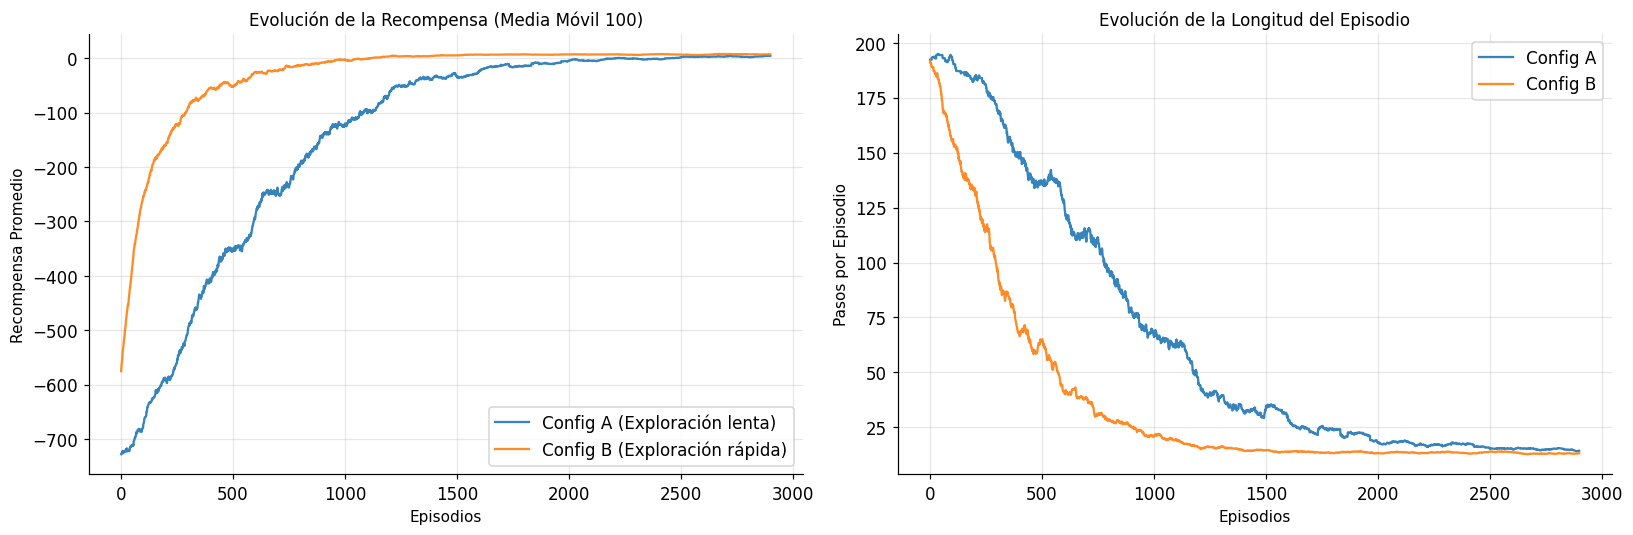

In [21]:
# Celda 11: Código (Gráficas de Recompensa y Longitud de Episodios)
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Recompensas
axs[0].plot(moving_average(stats_A, 100), label="Config A (Exploración lenta)", color="#1f77b4", alpha=0.9)
axs[0].plot(moving_average(stats_B, 100), label="Config B (Exploración rápida)", color="#ff7f0e", alpha=0.9)
axs[0].set_xlabel("Episodios")
axs[0].set_ylabel("Recompensa Promedio")
axs[0].set_title("Evolución de la Recompensa (Media Móvil 100)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Gráfica 2: Longitud de los episodios (Pasos)
axs[1].plot(moving_average(len_A, 100), label="Config A", color="#1f77b4", alpha=0.9)
axs[1].plot(moving_average(len_B, 100), label="Config B", color="#ff7f0e", alpha=0.9)
axs[1].set_xlabel("Episodios")
axs[1].set_ylabel("Pasos por Episodio")
axs[1].set_title("Evolución de la Longitud del Episodio")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.1 Análisis Espacial de la Política: Heatmap de Valores Q

A diferencia de entornos simples como Frozen Lake, Taxi-v3 tiene un espacio de estados multidimensional: `(fila_taxi, col_taxi, loc_pasajero, destino)`.

Para visualizar qué ha aprendido el agente, vamos a aislar una situación específica: **El pasajero está en la posición 0 (Rojo) y quiere ir a la posición 1 (Verde)**. Evaluaremos el valor máximo de $Q(s, a)$ para cada celda de la cuadrícula 5x5 del mapa. Esto nos generará un *heatmap* que indica cómo de "valiosa" o "cercana al objetivo" considera el agente cada coordenada del mapa.

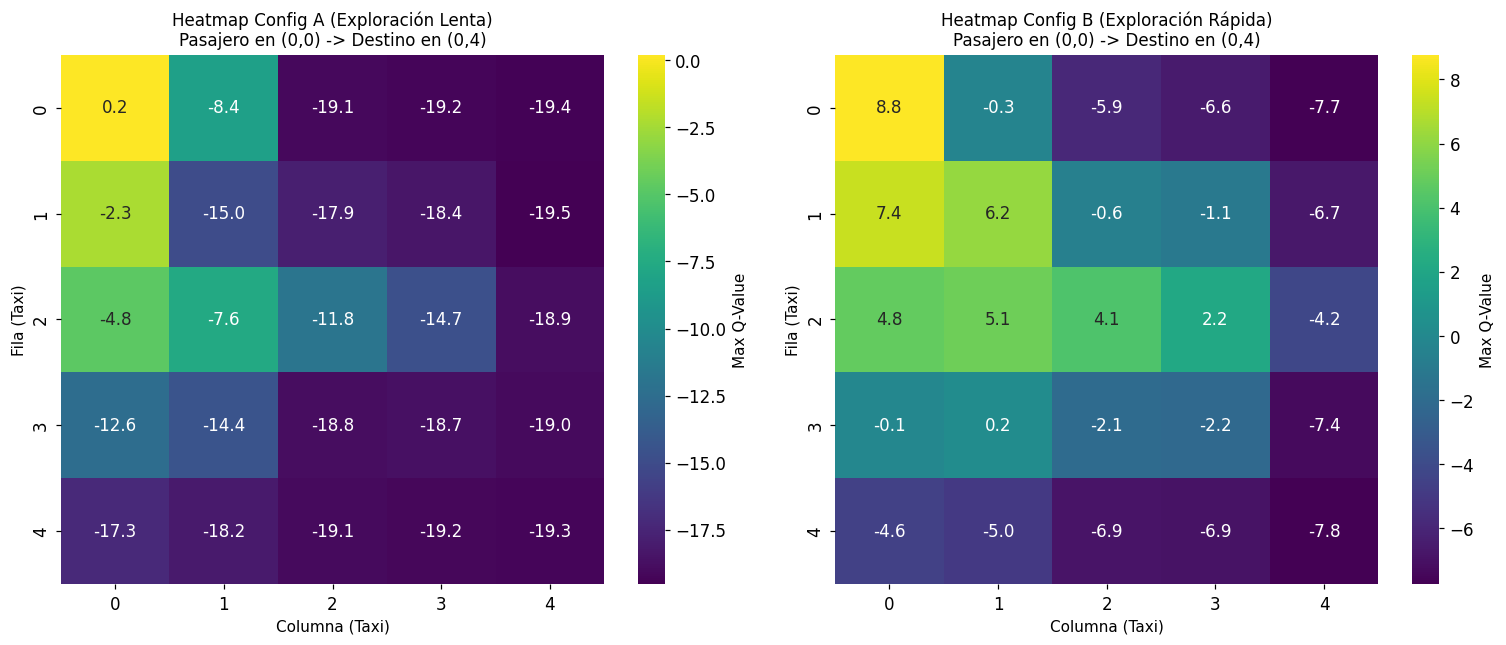

In [22]:
import seaborn as sns

# Decodificamos el entorno para un caso específico
# Pasajero en 0 (Red), Destino en 1 (Green)
pass_idx = 0
dest_idx = 1

# Creamos matrices 5x5 para almacenar los valores Max-Q
q_values_grid_A = np.zeros((5, 5))
q_values_grid_B = np.zeros((5, 5))

# Rellenamos las matrices consultando la Tabla Q entrenada
for row in range(5):
    for col in range(5):
        # env.unwrapped.encode empaqueta las coordenadas en un ID de estado (0-499)
        state_id = env.unwrapped.encode(row, col, pass_idx, dest_idx)

        # Guardamos el valor de la mejor acción posible en esa casilla
        q_values_grid_A[row, col] = np.max(Q_A[state_id])
        q_values_grid_B[row, col] = np.max(Q_B[state_id])

# Dibujamos los Heatmaps
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(q_values_grid_A, annot=True, fmt=".1f", cmap="viridis", ax=axs[0], cbar_kws={'label': 'Max Q-Value'})
axs[0].set_title("Heatmap Config A (Exploración Lenta)\nPasajero en (0,0) -> Destino en (0,4)")
axs[0].set_xlabel("Columna (Taxi)")
axs[0].set_ylabel("Fila (Taxi)")

sns.heatmap(q_values_grid_B, annot=True, fmt=".1f", cmap="viridis", ax=axs[1], cbar_kws={'label': 'Max Q-Value'})
axs[1].set_title("Heatmap Config B (Exploración Rápida)\nPasajero en (0,0) -> Destino en (0,4)")
axs[1].set_xlabel("Columna (Taxi)")
axs[1].set_ylabel("Fila (Taxi)")

plt.tight_layout()
plt.show()

## 4.2 Extracción de la Política Óptima (Learned Policy & Q-Values)

Dado que nuestro entorno tiene 500 estados, no podemos visualizar la tabla Q en su totalidad como se haría en un mapa de 4x4. Sin embargo, podemos "congelar" las variables del entorno (por ejemplo, definir que el pasajero está en la posición 0 y su destino es el 1) y proyectar sobre el mapa de 5x5 la **Política Óptima** aprendida.

Las acciones posibles se mapean de la siguiente manera:
* `0`: Sur (↓)
* `1`: Norte (↑)
* `2`: Este (→)
* `3`: Oeste (←)
* `4`: Recoger (P)
* `5`: Dejar (D)

In [26]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

def get_taxi_qtable_directions(qtable, env, pass_idx=0, dest_idx=1):
    """
    Extrae la matriz de valores Q máximos y los símbolos de las mejores acciones
    para una configuración específica del pasajero y destino en Taxi-v3.
    """
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    # Mapeo de acciones para Taxi-v3
    # 0: Sur, 1: Norte, 2: Este, 3: Oeste, 4: Recoger (P), 5: Dejar (D)
    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            # Decodificamos el estado para fijar al pasajero y el destino
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)

            best_action = int(np.argmax(qtable[state]))
            max_q_value = np.max(qtable[state])

            q_max_grid[row, col] = max_q_value
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid


def plot_taxi_q_values_map(qtable, env_name="Taxi-v3", pass_idx=0, dest_idx=1):
    '''
    Plotea el entorno real en un estado concreto junto con un mapa de calor
    (Heatmap) de la política aprendida y los valores Q máximos.
    '''
    # 1. Creamos un entorno temporal para renderizar la imagen
    env_render = gym.make(env_name, render_mode="rgb_array")
    env_render.reset()

    # Forzamos al entorno a estar en el estado que queremos visualizar
    # (Ej: Taxi en el centro (2,2) para que se vea bien el mapa)
    state_for_render = env_render.unwrapped.encode(2, 2, pass_idx, dest_idx)
    env_render.unwrapped.s = state_for_render
    img = env_render.render()
    env_render.close()

    # 2. Obtenemos las matrices de valores y direcciones
    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env_render, pass_idx, dest_idx)

    # 3. Configuramos el gráfico
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    # Panel Izquierdo: Imagen del entorno
    ax[0].imshow(img)
    ax[0].axis("off")
    ax[0].set_title(f"Vista del Entorno\n(Pasajero en loc {pass_idx}, Destino {dest_idx})", fontsize=14)

    # Panel Derecho: Heatmap de la Política
    sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True), # Mantenemos la paleta "Blues"
        linewidths=1.5,
        linecolor="black", # Líneas negras para que resalte la cuadrícula (como en Frozen Lake)
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"}, # Letras y flechas muy claras
    )
    ax[1].set_title("Learned Q-values\nArrows and letters (P/D) represent best action", fontsize=14)

    # Borde negro para el heatmap
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

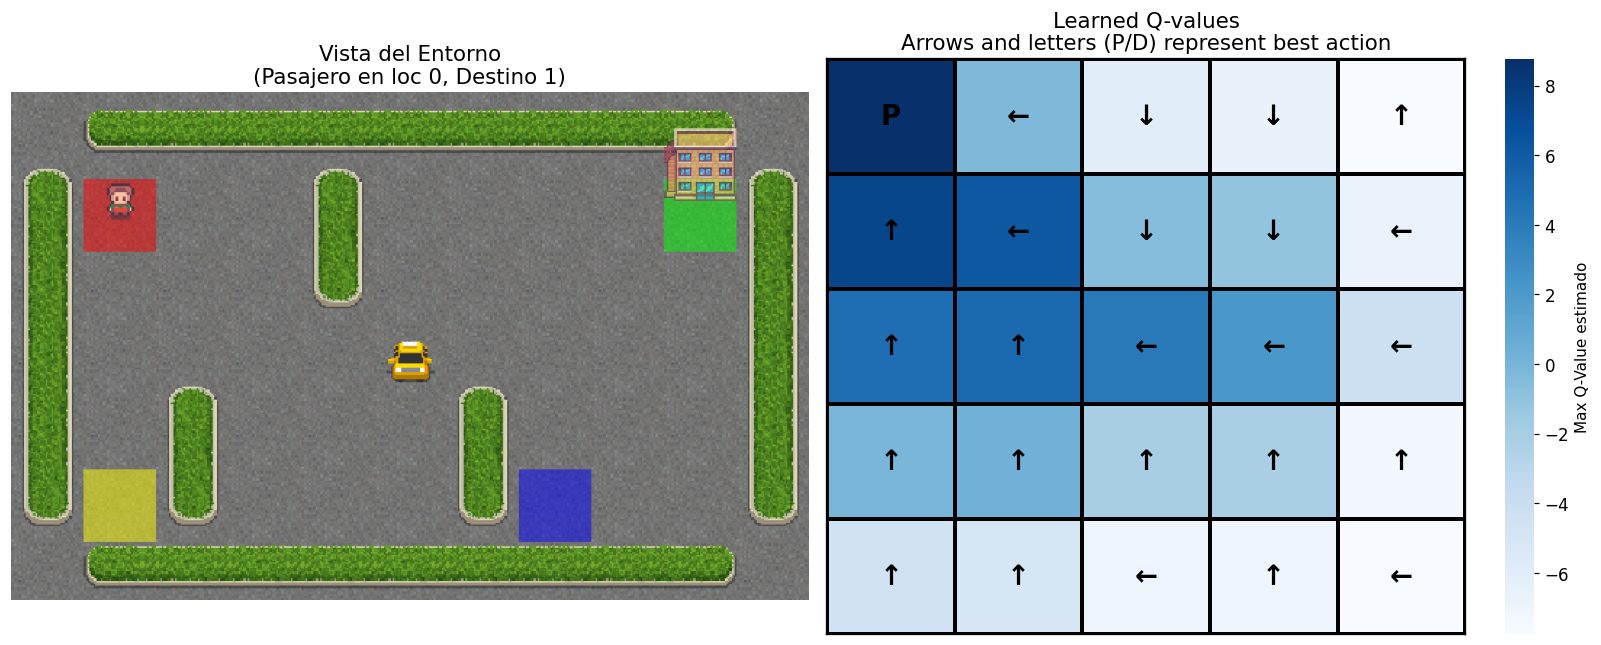

In [27]:
# Mostramos el mapa de la política aprendida (Config B)
# Pasajero en la ubicación 0 (Rojo), Destino en la 1 (Verde)
plot_taxi_q_values_map(Q_B, env_name="Taxi-v3", pass_idx=0, dest_idx=1)

## 5. Visualización del Agente en Acción

Al igual que analizamos las métricas numéricas, es fundamental observar cualitativamente cómo se comporta el agente tras el entrenamiento. A continuación, vamos a crear una función que ejecute un episodio utilizando la tabla Q aprendida (explotación pura, sin exploración) y capture los fotogramas para generar un GIF.

In [18]:
# Es posible que necesites imageio para guardar el GIF fácilmente
!pip install imageio --quiet

import imageio
from IPython.display import Image, display

def play_and_record(env_name, Q_table, filename, max_steps=50):
    """
    Ejecuta un episodio completo usando la tabla Q entrenada,
    captura los frames y los guarda como un GIF.
    """
    # Usamos render_mode='rgb_array' para capturar las imágenes
    env_render = gym.make(env_name, render_mode="rgb_array")
    state, _ = env_render.reset()

    frames = []
    done = False
    step = 0

    # Capturamos el frame inicial
    frames.append(env_render.render())

    while not done and step < max_steps:
        # Explotación pura: elegimos la mejor acción según la tabla Q
        action = np.argmax(Q_table[state, :])

        next_state, reward, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated

        frames.append(env_render.render())
        state = next_state
        step += 1

    env_render.close()

    # Guardamos los frames como GIF
    imageio.mimsave(filename, frames, fps=5)
    print(f"Episodio finalizado en {step} pasos. GIF guardado en: {filename}")

### 5.1 Rendimiento de la Configuración A (Exploración Lenta)
Visualizamos cómo el agente entrenado con la configuración de exploración lenta resuelve el problema de recoger y dejar al pasajero.

Episodio finalizado en 13 pasos. GIF guardado en: taxi_sarsa_config_A.gif


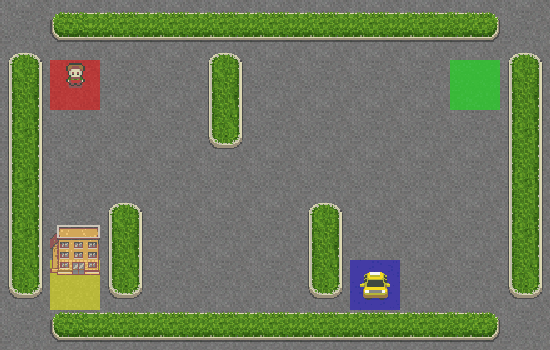

In [19]:
gif_path_A = "taxi_sarsa_config_A.gif"

# Grabamos el GIF usando la tabla Q de la configuración A
play_and_record("Taxi-v3", Q_A, gif_path_A)

# Mostramos el GIF en el notebook
display(Image(open(gif_path_A, 'rb').read()))

### 5.2 Rendimiento de la Configuración B (Exploración Rápida)
Comprobamos si el agente que dejó de explorar rápidamente es capaz de resolver el entorno de forma tan eficiente como el anterior.

Episodio finalizado en 7 pasos. GIF guardado en: taxi_sarsa_config_B.gif


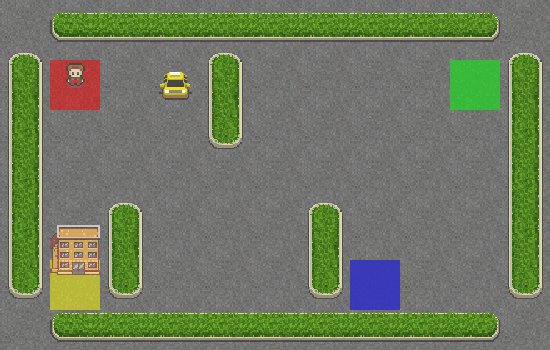

In [20]:
gif_path_B = "taxi_sarsa_config_B.gif"

# Grabamos el GIF usando la tabla Q de la configuración B
play_and_record("Taxi-v3", Q_B, gif_path_B)

# Mostramos el GIF en el notebook
display(Image(open(gif_path_B, 'rb').read()))

### Conclusiones del Análisis

1. **Eficiencia del Aprendizaje (Recompensa vs. Pasos):** Observamos que los episodios comienzan tomando cientos de pasos (con fuertes penalizaciones de -1). A medida que avanza el entrenamiento, la línea de pasos converge a su mínimo teórico y las recompensas se estabilizan cerca de +10 / +15 de media (lo cual es óptimo, ya que la ruta más corta sigue restando 1 punto por movimiento).
2. **Impacto de la Tasa de Exploración:** La **Configuración A** tarda más episodios en alcanzar la convergencia de recompensa por su decaimiento lento, pero asegura explorar más rutas. La **Configuración B** sube rápidamente su recompensa, pero corre el riesgo de quedarse atascada en óptimos locales si el entorno fuera estocástico.
3. **Interpretación del Heatmap:** El gradiente de color nos muestra perfectamente el "camino de migas de pan" que ha construido el agente. Los valores Q más altos (colores más claros) se agrupan de forma lógica alrededor del objetivo o de las rutas que evitan los muros del mapa, demostrando que la retropropagación del error de diferencia temporal ha mapeado el entorno 5x5 correctamente.

### ¿Por qué la gráfica $f(t) = len(episodio_t)$ es un buen indicador de aprendizaje?
Tal y como se solicita en los requisitos de la práctica, hemos incluido la evolución temporal de la longitud del episodio (pasos por episodio). Esta métrica es un indicador de aprendizaje excelente, a veces incluso superior a la recompensa bruta, por dos motivos:
1. **Eficiencia de la ruta:** En entornos como *Taxi-v3*, donde cada movimiento penaliza con -1, la única forma de maximizar la recompensa es minimizando los pasos. La curva de longitud nos muestra visualmente cómo el agente deja de deambular de forma aleatoria (exploración) y comienza a trazar la ruta geodésica más corta hacia su objetivo.
2. **Aislamiento del ruido:** La recompensa total puede dar saltos bruscos (por ejemplo, el +20 al dejar al pasajero o el -10 por un error). Sin embargo, la métrica de pasos decrece de forma mucho más suave y monótona, permitiendo observar con mayor precisión en qué momento exacto convergen las políticas (en nuestro caso, alrededor de los 1500 episodios para la Configuración B).